**Data Cleaning and Processing**

EPIC - RL2 - SP3

Paulo Yoshio Kuga

In [1]:
import lissa as li
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import json

The one-hour frequency file is supposed to be loaded into base_data. Then, data has its types infered and time is defined as time. 

Nonetheless, the duplicates are delete and the data is exported.

But it's expected to work in any file that has the same headers that what came for us in the aforementioned file.

In [2]:
file_dir = "../data"
file_name = "full_sensor_1h [old].csv"

# Path to file
file_path = file_dir + "/" + file_name

# Read data and convert to respective type
base_data = pd.read_csv(file_path, delimiter=",")
base_data = base_data.infer_objects(copy=False)
base_data["time"] = pd.to_datetime(base_data["time"])
base_data["Well"] = base_data["Well Run"].str[:4]

print(
    f"Pumps: #{base_data['Well'].unique().size}\n"
    f"Runs: #{base_data['Well Run'].unique().size}"
)


# Identify and remove duplicate rows
columns_for_dup_check = list(set(list(base_data)) - {"Well_down", "Well Run"})
dup = base_data[columns_for_dup_check].duplicated()
base_data.drop(index=base_data[dup].index, columns="Well", inplace=True)

# entire_data,pumpList = li.FailureMerge(base_data,"../data","respostas.csv")
# entire_data = li.FeatureCreation(entire_data)
# total_data = li.ProcessData(pumpList,entire_data,total_dataPath="../data/totalProcessedData.csv")

Pumps: #38
Runs: #57


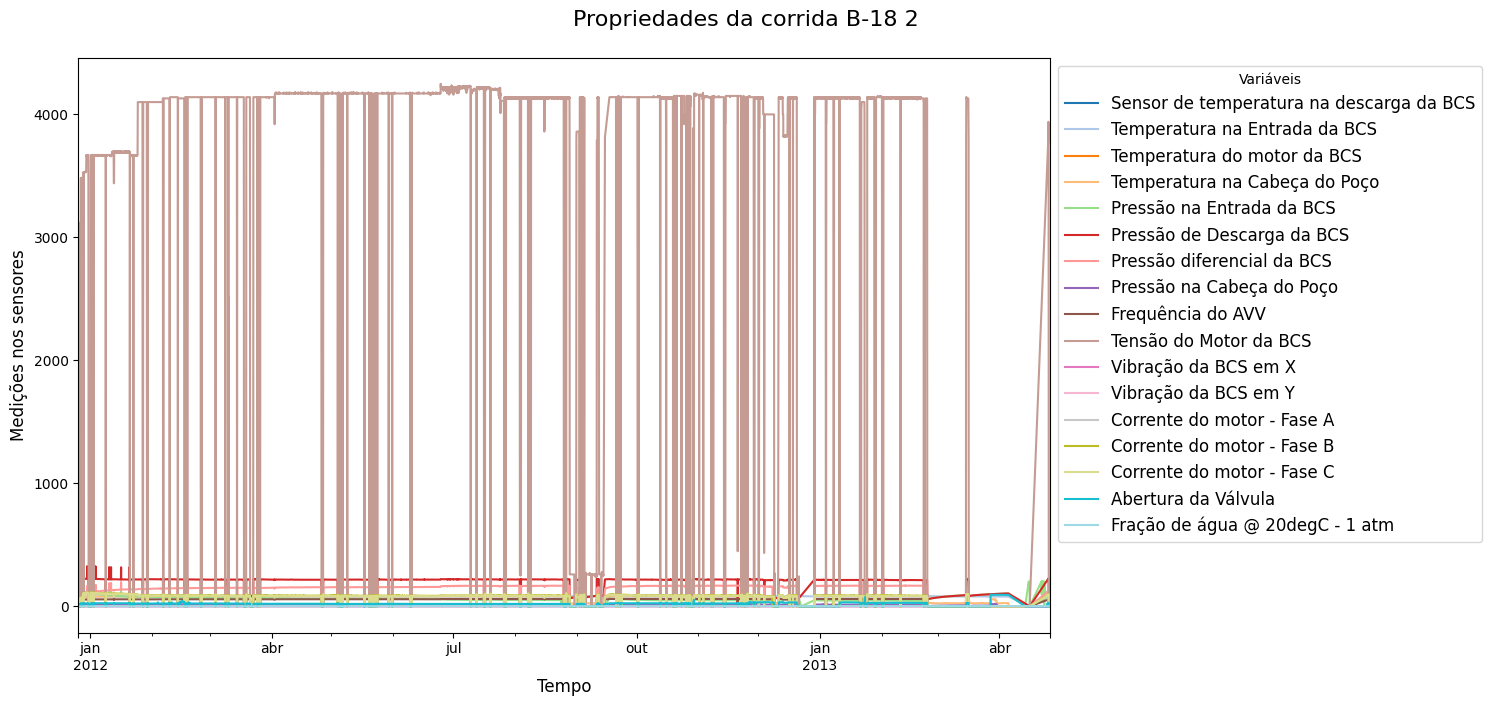

In [11]:
pump = "B-18 2"
export_data = (base_data.loc[base_data["Well Run"] == pump].copy()) #copies the original dataset

export_data.set_index("time",inplace=True)

figure = (li.LissaFigure(path="./plots/original_properties.json")
 .set_translation()
 .set_figure()
 .time_series_plot(export_data)
 )


Then, the file respostas.csv is called. respostas.csv is an PEREGRINO ESP Run Life fail spreadsheet.

This file is loaded with the intent of allowing our data be linked with faliure date.

A column, called "Well_down" was created by Equinor, analyzing if the well was on off or online. 

Having the faliure date at main data, it is possible to realize a comparision between the dates and infer if there will be a faliure or not. Therefore, with this approach, we can label all data, if it's relatable with a faliure or not.

However, this approach does not point exactly when it was observed the faliure, but, in reality, only labels if the proababilty of the anomaly is inside the subset is greater.

In [3]:
failure_file = "respostas.csv"

filePath = file_dir + "/" + failure_file #path to file
respostas = pd.read_csv(filePath, delimiter=",") #import faliure data

# Filter all pump names in the dataset
pump_list = base_data["Well Run"].unique()

# Only analyze data that is in the time dataset
respostas = respostas.loc[respostas["Well Run"].isin(pump_list)]

# Failure precise time is not considered in the dataset, since it's only a report
respostas["Failure Date"] = pd.to_datetime(
    respostas["Failure Date"],
    format="%d/%m/%y"
).dt.tz_localize('UTC')

# Do a left merge to unite failure date with time info
entire_data = pd.merge(base_data, respostas, how="left", on="Well Run")

# Check if failure already happened
entire_data["Failure"] = entire_data["time"] >= entire_data["Failure Date"]

# Remove duplicated columns
drop_list = ['Start-up Date', 'Start-up Date', 'ESP Failure?', 'Failure Date']
entire_data.drop(drop_list, axis=1, inplace=True)

# Time is set as index
entire_data.set_index("time", inplace=True)

 This function is intended to process columns for feature creation. 

Currently is only synthetizing current A,B,C in a norm-2, doing the same for vibrations and converting columns written as 1/100 units in fractions.

Users might want to deal with new features. It is not the best pratice, but they should be written here (inside the function).

In [4]:
entire_data["ESP Current Module"] = (
entire_data["ESP motor Current - phase A"].pow(2)+
entire_data["ESP motor Current - phase B"].pow(2)+
entire_data["ESP motor Current - phase C"].pow(2)).pow(1/2)

entire_data["ESP Vibration Module"] = (entire_data["ESP Vibration X"].pow(2)+entire_data["ESP Vibration Y"].pow(2)).pow(1/2)

entire_data["ESP Motor Voltage"] = entire_data["ESP Motor Voltage"]/1000

entire_data["Choke Opening"] = entire_data["Choke Opening"]/100
entire_data["Water Cut @ 20degC - 1 atm"] = entire_data["Water Cut @ 20degC - 1 atm"]/100


entire_data.drop(columns=[
    # "Current Mean",
    "ESP motor Current - phase A",
    "ESP motor Current - phase B",
    "ESP motor Current - phase C",
    "ESP Vibration X",
    "ESP Vibration Y",
    'ESP differential pressure', #we are going to try to find this in PCA
    "ESP discharge temperature sensor" #there's too many few entries to be considered.

],inplace=True)


In [5]:
with open("./dictionaries/headers.json","r") as dictionary:
    headers = json.load(dictionary)

numerical_headers = list(set(entire_data.columns)-set(headers["information"])-set(headers["percentual"]))
numerical_headers.sort()
new_dict = {
    "numerical_headers":numerical_headers,
    "non_numerical_headers": headers["information"]
    }

with open("./dictionaries/new_headers.json", "w") as file:
    json.dump(new_dict, file, indent=4)

For each pump, for selected numerical properties, a low frequency filter is passed, trying to reduce the noise into the data. 

In [6]:
total_data = pd.DataFrame(columns=list(entire_data))

for pump in pump_list:
    # Copies the original dataset
    export_data = entire_data.loc[entire_data["Well Run"] == pump].copy()
    
    # Apply exponential weighted mean and standardization filter
    filter_data = export_data.groupby("Well_down")[numerical_headers].apply(
        lambda x: (x.ewm(span=24).mean() - x.expanding().median()) / x.expanding().std()
    )
    
    filter_data = (
        filter_data
        .reset_index()
        .set_index("time")
        .fillna(0)
        .sort_index()
        .drop(columns="Well_down")
    )
    
    total_data = pd.concat(
        [
            total_data,
            pd.merge(filter_data, export_data[headers["information"]+headers["percentual"]], how="left", on="time")
        ],
        axis=0
    )

#total_data.reset_index(inplace=True)
#total_data.to_csv("../data/totalProcessedData.csv")
#total_data.set_index("index", inplace=True)

/tmp/ipykernel_231557/241539414.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  total_data = pd.concat(
/tmp/ipykernel_231557/241539414.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_data = pd.concat(


Text(0.5, 52.7222222222222, 'Time')

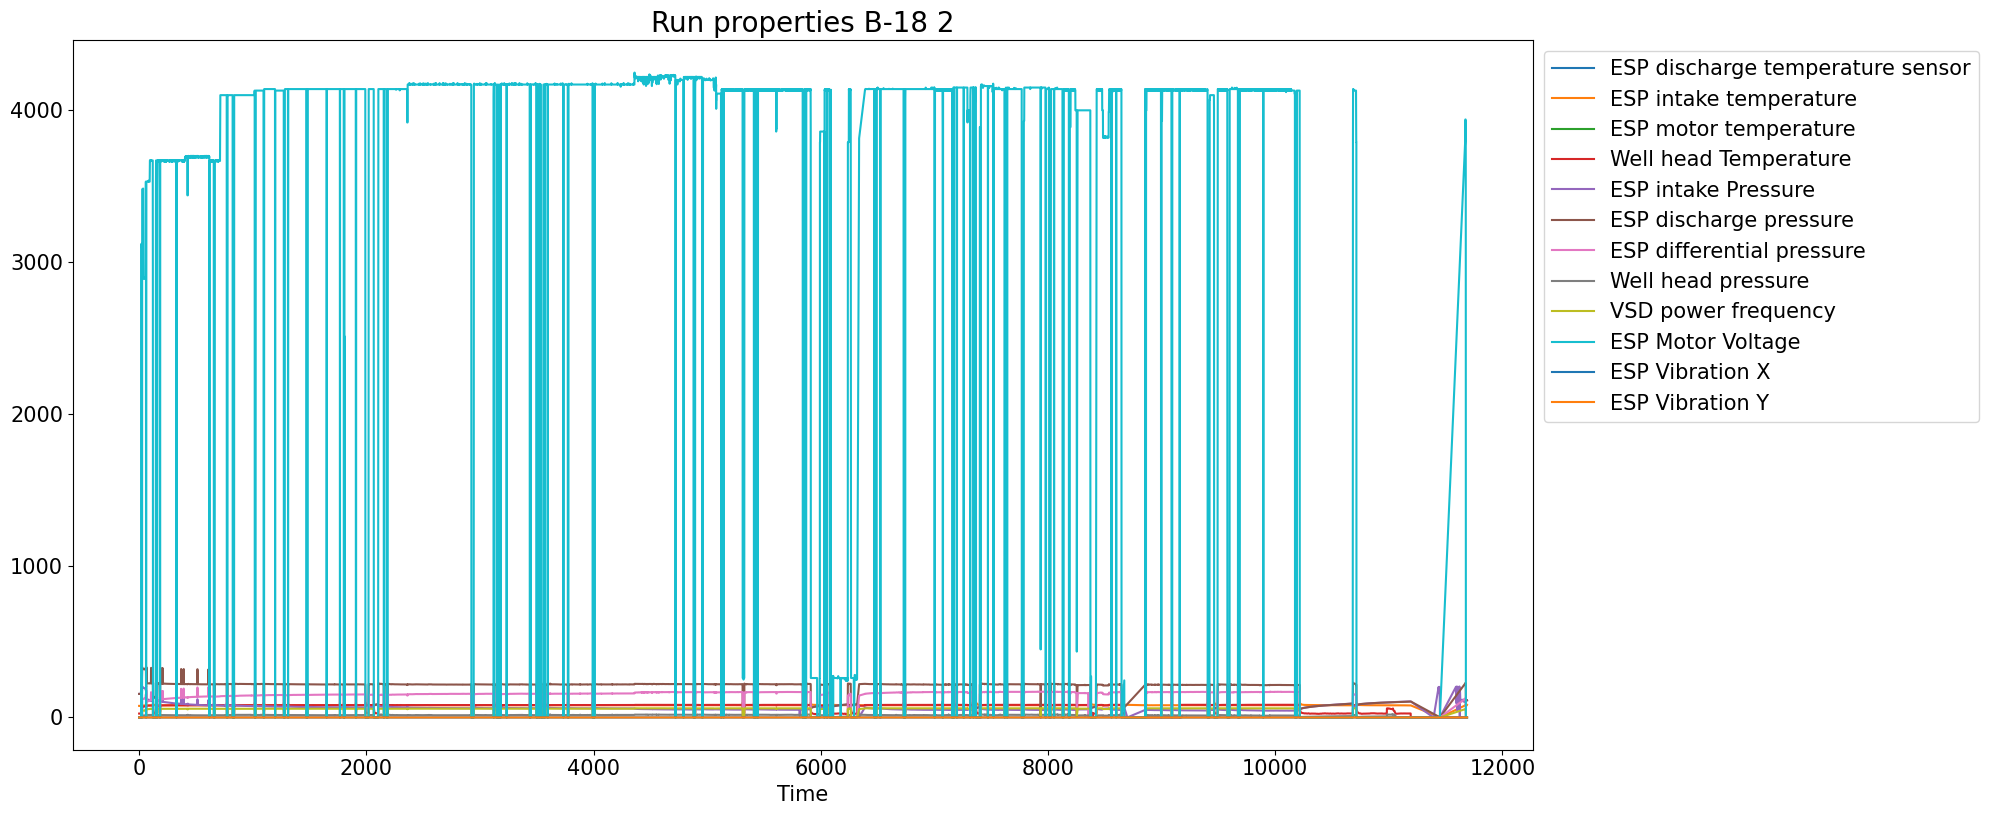

In [ ]:



#export_data["Tempo"] = pd.to_datetime(export_data["time"])
#export_data.set_index("Tempo",drop=True,inplace=True)

Headers = [
'ESP discharge temperature sensor',
'ESP intake temperature',
'ESP motor temperature',
'Well head Temperature',
'ESP intake Pressure',
'ESP discharge pressure',
'ESP differential pressure',
'Well head pressure',
'VSD power frequency',
'ESP Motor Voltage',
"ESP Vibration X",
"ESP Vibration Y"
#'Current Mean',
#'ESP Vibration Module',
#'ESP Power',

]

export_data[Headers].plot(figsize=(20,8),fontsize=15)

# plt.figure(figsize=(20,10))
# plt.scatter(export_data.index,export_data["ESP Motor Voltage"])

plt.legend([li.Traducao(item,True) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
#plt.title("Propriedades da corrida " + pump,fontsize=20)
plt.title("Run properties " + pump,fontsize=20)
plt.tight_layout(pad=1.1)
#plt.xlabel("Tempo",fontsize=15)
plt.xlabel("Time",fontsize=15)
#plt.savefig("../imagens_gerais/crude_data",bbox_inches='tight')
#plt.close()


In [9]:
export_data[Headers].plot(figsize=(20,8),logy=True,fontsize=15)

plt.legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
plt.title("Propriedades da corrida " + pump,fontsize=20)
plt.tight_layout(pad=1.1)
plt.xlabel("Tempo",fontsize=15)
plt.savefig("../imagens_gerais/crude_data_log",bbox_inches='tight')
plt.close()

In [10]:
li.PropertyTableGenerator(
    (base_data.isna().sum(axis=0)/base_data.shape[0]).reset_index(),
    name="tabela_vazios.csv"
    ) #tabela vazios


li.PropertyTableGenerator(
    entire_data.describe().T[["mean","std"]],
    name="tabela_posprocessamento.csv"
    ) #tabela vazios

li.PropertyTableGenerator(
    base_data.describe().T[["mean","std"]],
    path="./",name="propriedades.csv")


NotADirectoryError: [Errno 20] Not a directory: '/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/picture.py/dictionaries/dictionaries.json'

In [ ]:
pump = "B-18 2"
export_data = (entire_data.loc[entire_data["Well Run"] == pump].copy()) #copies the original dataset

Headers = [
#'ESP discharge temperature sensor',
'ESP intake temperature',
'ESP motor temperature',
'Well head Temperature',
'ESP intake Pressure',
'ESP discharge pressure',
#'ESP differential pressure',
'Well head pressure',
'VSD power frequency',
'ESP Motor Voltage',
'ESP Current Module',
'ESP Vibration Module',
#'ESP Power',
#"ESP Vibration X",
#"ESP Vibration Y"
]

#Filter = export_data.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*windowSize).mean()-x.expanding().median())/x.expanding().std())

Measure = export_data.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*1).mean()-x.expanding().median()))
MAD = Measure.apply(lambda x: x.abs().expanding().median())

# Filter = SeriesBack(Measure)/SeriesBack(MAD)


Z = li.SeriesBack(Measure)/(li.SeriesBack(MAD)*1.4826)

removedHeaders = [
    'Water Cut @ 20degC - 1 atm',
    'Choke Opening',
    "Well aligned to Train A",
    "Well aligned to Train B",
    'Failure Info',
    'Pump Info',
    "Well Run",
    "Failure",
    "Well_down"
    
    ]

data = pd.merge(Z,export_data[removedHeaders],how="left",on="time")

fig,axs = plt.subplots(2,1,figsize=(20,10))

plt.rcParams["font.size"]=15



export_data[Headers].expanding().std().plot(ax=axs[0],logy=True,sharex=True)
axs[0].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[0].title.set_text("Desvio Padrão")#"Standard Deviation")
axs[0].title.set_fontsize(20)


(li.SeriesBack(MAD)*1.4826)[Headers].plot(ax=axs[1],logy=True)
axs[1].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[1].title.set_text("Desvio Absoluto - MAD")#"Mean Absolute Deviation")
axs[1].title.set_fontsize(20)
plt.tight_layout(pad=1.1)
axs[1].set_xlabel("Tempo")

fig.savefig("../imagens_gerais/madvsnormal_pt.jpg",bbox_inches='tight')
plt.close()


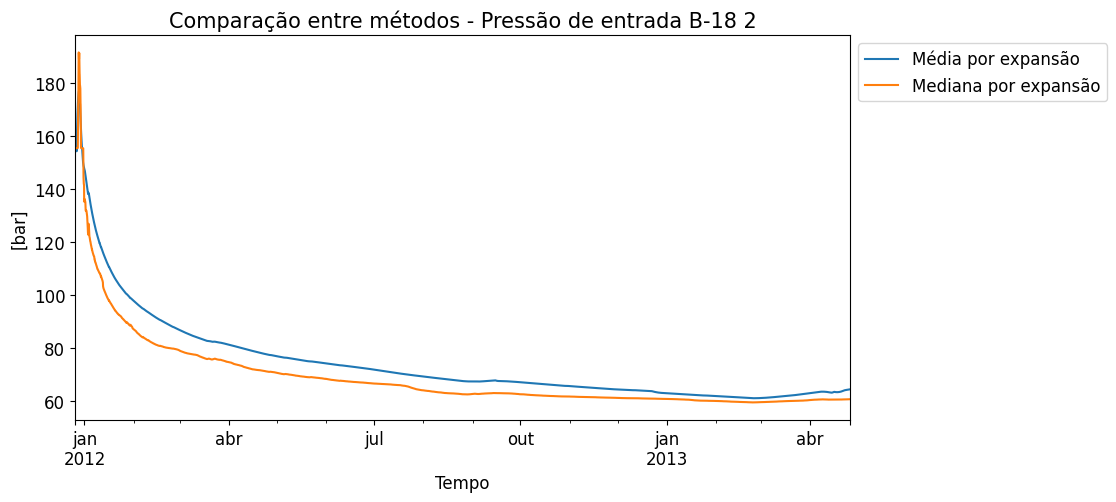

In [ ]:
plt.rcParams["font.size"]=12
fig,axs = plt.subplots(1,1,figsize=(10,5))
export_data["ESP intake Pressure"].expanding().mean().plot(ax=axs)
export_data["ESP intake Pressure"].expanding().median().plot(ax=axs)

axs.title.set_text("Comparação entre métodos - Pressão de entrada B-18 2")#"Standard Deviation")
axs.title.set_fontsize(15)

axs.legend(["Média por expansão","Mediana por expansão"],loc='upper left',bbox_to_anchor=(1, 1),fontsize=12)
axs.set_xlabel("Tempo")
axs.set_ylabel("[bar]")

# axs[1].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
# axs[1].title.set_text("Mediana por Expansão")#"Mean Absolute Deviation")
# axs[1].title.set_fontsize(20)
# plt.tight_layout(pad=1.1)


fig.savefig("../imagens_gerais/meanvsmedian_pt.jpg",bbox_inches='tight')
#plt.close()

In [ ]:
base_dataHeaders = [
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP motor Current - phase A',
    'ESP motor Current - phase B',
    'ESP motor Current - phase C',
    'ESP Vibration X',
    'ESP Vibration Y'
    ]


Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration X',
    #'ESP Vibration Y'
    "ESP Vibration Module"
    #'ESP Power'

    ]

In [ ]:
percentual = ((entire_data[Headers]-entire_data[Headers].min(axis=0))/(entire_data[Headers].max(axis=0)-entire_data[Headers].min(axis=0)))

percentual.describe().T

,count,mean,std,min,25%,50%,75%,max
ESP intake temperature,1254646.0,0.414539,0.040334,0.0,0.409535,0.419061,0.427669,1.0
ESP motor temperature,1223111.0,0.676858,0.041305,0.0,0.640379,0.682427,0.704749,1.0
Well head Temperature,1350750.0,0.506119,0.251872,0.0,0.236696,0.682696,0.713043,1.0
ESP intake Pressure,1252917.0,0.335442,0.069116,0.0,0.281059,0.321804,0.397497,1.0
ESP discharge pressure,1254423.0,0.492933,0.101316,0.0,0.477332,0.523857,0.550663,1.0
Well head pressure,1350750.0,0.052076,0.033594,0.0,0.031615,0.056154,0.066000,1.0
VSD power frequency,1362103.0,0.509560,0.401803,0.0,0.000143,0.771571,0.857714,1.0
ESP Motor Voltage,1362103.0,0.492671,0.385727,0.0,0.000000,0.754718,0.824445,1.0
ESP Current Module,1362103.0,0.026362,0.021342,0.0,0.000000,0.035675,0.045663,1.0
ESP Vibration Module,1353798.0,0.004019,0.006775,0.0,0.000458,0.002748,0.004871,1.0


In [ ]:
#pd.plotting.boxplot_frame(percentual,figsize=(20,10))

In [ ]:
fig,axes = li.Histogram(
    entire_data.loc[entire_data["Well_down"]==0][Headers],
    "Histogramas dos dados originais",figsizeT=(20,18),layout=(4,3))

plt.savefig("../imagens_gerais/hist_original.jpg",bbox_inches='tight')
plt.close()

In [ ]:
boxplot_data = entire_data.loc[entire_data["Well_down"]==0][Headers].copy().fillna(0)
#boxplot_data["ESP Motor Voltage"] = boxplot_data["ESP Motor Voltage"]/1000
pd.plotting.boxplot(((boxplot_data-boxplot_data.min())/(boxplot_data.max()-boxplot_data.min())),figsize=(30,10))


plt.rcParams["font.size"]=20
plt.suptitle("Diagramas de Caixa dos dados Originais",fontsize=20) #Original Data BoxPlots" 
plt.tight_layout(pad=1.3)
plt.savefig("../imagens_gerais/boxplot_original.jpg",bbox_inches='tight')
plt.close()

In [ ]:
pump = pumpList[0]

pumpData = entire_data.loc[entire_data["Well Run"]==pump]
pumptotal_data = total_data.loc[total_data["Well Run"]==pump]

fig,axs = plt.subplots(2,2,figsize=(15,6),sharex=True)
plt.rcParams["font.size"]=10


pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[0,0],color="blue")

pumpData["ESP intake Pressure"].expanding().median().plot(ax=axs[0,1])
pumpData["ESP intake Pressure"].expanding().std().plot(ax=axs[1,0],color="orange")


pumptotal_data["ESP intake Pressure"].plot(ax=axs[1,1],color="red")



# axs[0,0].set_xlabel("time")
# axs[1,1].set_xlabel("time")

axs[0,0].set_ylabel("[bar]")
axs[0,1].set_ylabel("[bar]")
axs[1,0].set_ylabel("[bar]")
axs[1,1].set_ylabel("[-]")

# axs[0,0].set_title("Filtered Signal",fontsize=9)
# axs[0,1].set_title("Expanding Median",fontsize=9)
# axs[1,0].set_title("Expanding Standard-Deviation",fontsize=9)
# axs[1,1].set_title("Normalized Signal",fontsize=9)
# fig.suptitle("ESP intake Pressure - Run: " + pump)
# plt.tight_layout()



# plt.savefig("../imagens_gerais/z_score_formation.jpg")
# plt.close()

axs[1,0].set_xlabel("Tempo")
axs[1,1].set_xlabel("Tempo")



axs[0,0].set_title("Sinal Filtrado",fontsize=9)
axs[0,1].set_title("Mediana por Expansão",fontsize=9)
axs[1,0].set_title("Desvio-padrão por expansão",fontsize=9)
axs[1,1].set_title("Sinal Normalizado",fontsize=9)
fig.suptitle("Pressão na Entrada da ESP - Corrida: " + pump)

plt.savefig("../imagens_gerais/z_score_formation_pt.jpg",bbox_inches='tight')
plt.close()


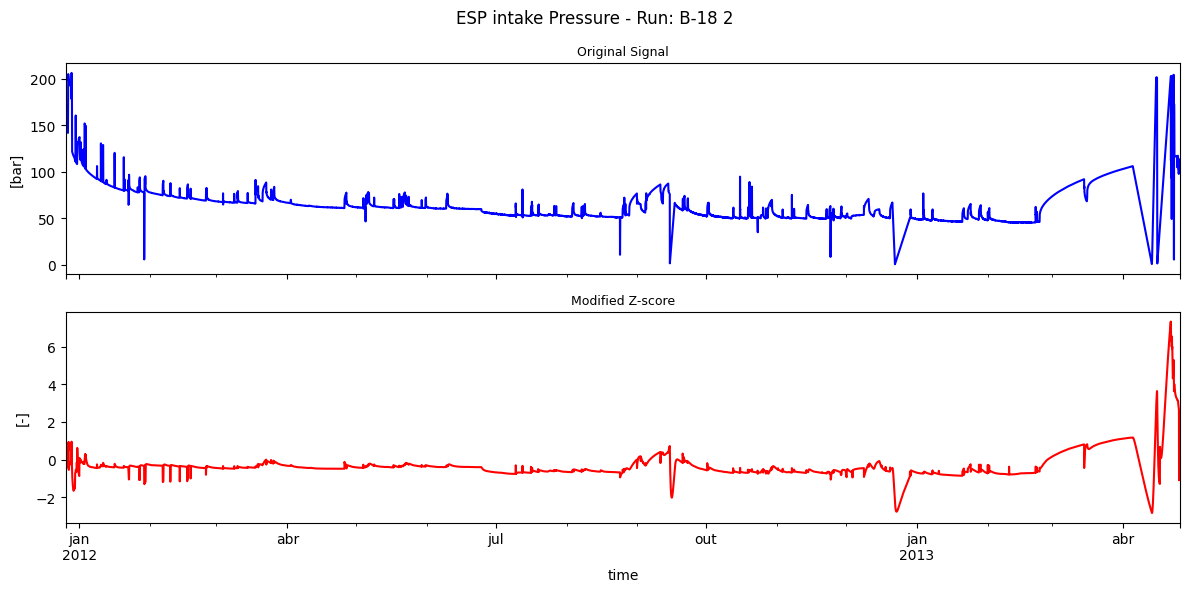

In [ ]:
pump = pumpList[0]

pumpData = entire_data.loc[entire_data["Well Run"]==pump]
pumptotal_data = total_data.loc[total_data["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(12,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="blue")
pumptotal_data["ESP intake Pressure"].plot(ax=axs[1],color="red")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Modified Z-score",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

#plt.savefig("../imagens_gerais/pressao_b18_2.jpg",bbox_inches='tight')
#plt.close()


In [ ]:
pump = pumpList[0]

pumpData = entire_data.loc[entire_data["Well Run"]==pump]
pumptotal_data = total_data.loc[total_data["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="blue")
pumptotal_data["ESP intake Pressure"].plot(ax=axs[1],color="red")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered and Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg",bbox_inches='tight')
plt.close()


In [ ]:
pump = pumpList[0]

pumpData = entire_data.loc[entire_data["Well Run"]==pump]
pumptotal_data = total_data.loc[total_data["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(10,5),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("Tempo")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Sinal Original",fontsize=9)
axs[1].set_title("Sinal Filtrado",fontsize=9)
fig.suptitle("Pressão de Entrada na corrida: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2_pt.jpg",bbox_inches='tight')
plt.close()



In [ ]:
pump = pumpList[0]

pumpData = entire_data.loc[entire_data["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(10,5),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg",bbox_inches='tight')
plt.close()


In [ ]:
plt.rcParams["font.size"]=12
li.ZScorePlot(total_data,pump,Headers)
plt.legend([li.Traducao(item) for item in Headers])
plt.suptitle("Dados da corrida "+ pump + " com o Z-score modificado",fontsize=16)
plt.xlabel("Tempo")

plt.savefig("../imagens_gerais/Zscore.jpg", bbox_inches='tight')

plt.close()


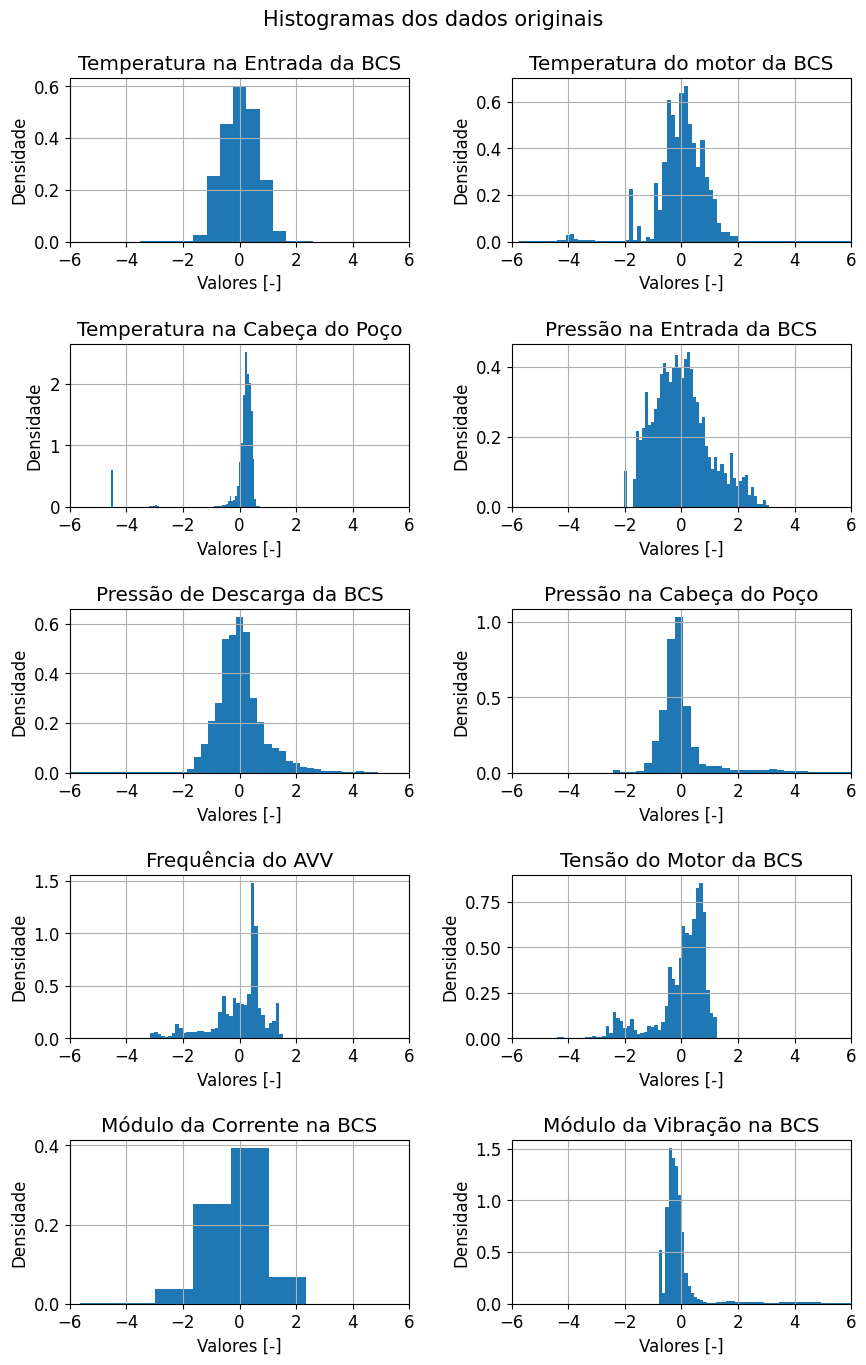

In [ ]:
x = entire_data.loc[entire_data["Well_down"]==0][Headers]

Z = (x - x.mean())/x.std()

axes = Z.hist(bins=100,figsize=(9,14),density=True,layout=(5,2))

i = 0
measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","kV","A","g","g","-"]

for ax in axes.flatten():
    ax.set_title(li.Traducao(ax.get_title()))
    ax.set_xlabel("Valores [-]",fontsize=12)  # Define a legenda com o nome da coluna
    ax.set_ylabel("Densidade",fontsize=12)
    ax.set_xlim([-6,6])
    i += 1


plt.suptitle("Histogramas dos dados originais",fontsize=15)
plt.tight_layout(pad=1.6)
plt.savefig("../imagens_gerais/Z-hist.jpg",bbox_inches='tight')
#plt.close()

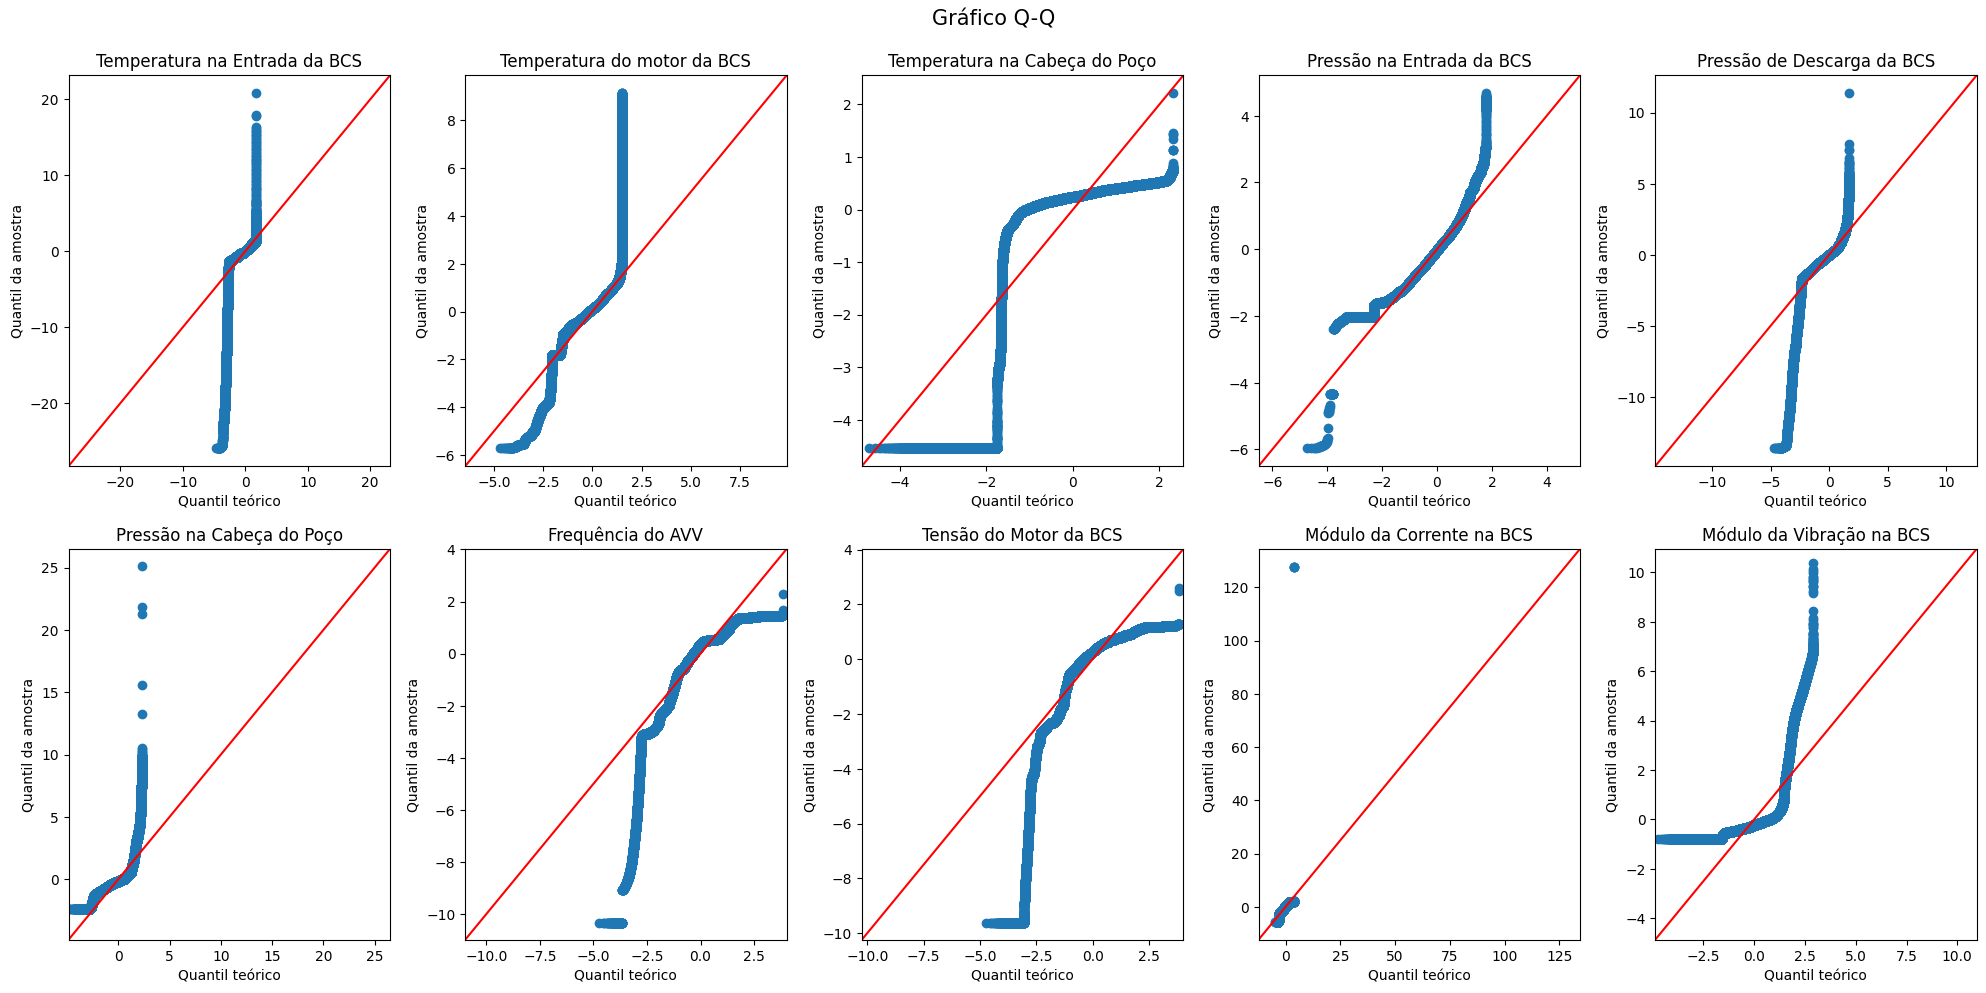

In [ ]:
fig, axs = li.QQPlots(Z,Headers,lineType="45",english=False, titleFontsize=15,ydist=0.99,figSizeSt=(20,10),generalFontSize=10, title="Gráfico Q-Q",layout=(2,5))
fig.savefig("../imagens_gerais/QQplot_pt",bbox_inches='tight')
#plt.close()

In [ ]:
# x = total_data.loc[total_data["Well_down"]==0][Headers].apply(np.log1p).abs()

# axes = x.hist(bins=100,figsize=(20,20),density=True)

# i = 0
# measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","kV","A","g","g","-"]


# for ax in axes.flatten():
#     ax.set_title(li.Traducao(ax.get_title()))
#     ax.set_xlabel("Valores [" +measures[i]+"]" )  # Define a legenda com o nome da coluna
#     ax.set_ylabel("Densidade")
#     #ax.set_xlim([-6,6])
#     i += 1


# plt.suptitle("Histogramas dos dados originais",fontsize=20)
# plt.tight_layout(pad=1.6)
# #plt.savefig("../imagens_gerais/Z-hist.jpg")